# Perturbed Pixel

This notebook merges the VGG16 property results with per-image object ratios and writes a clean CSV for downstream L0 analysis.

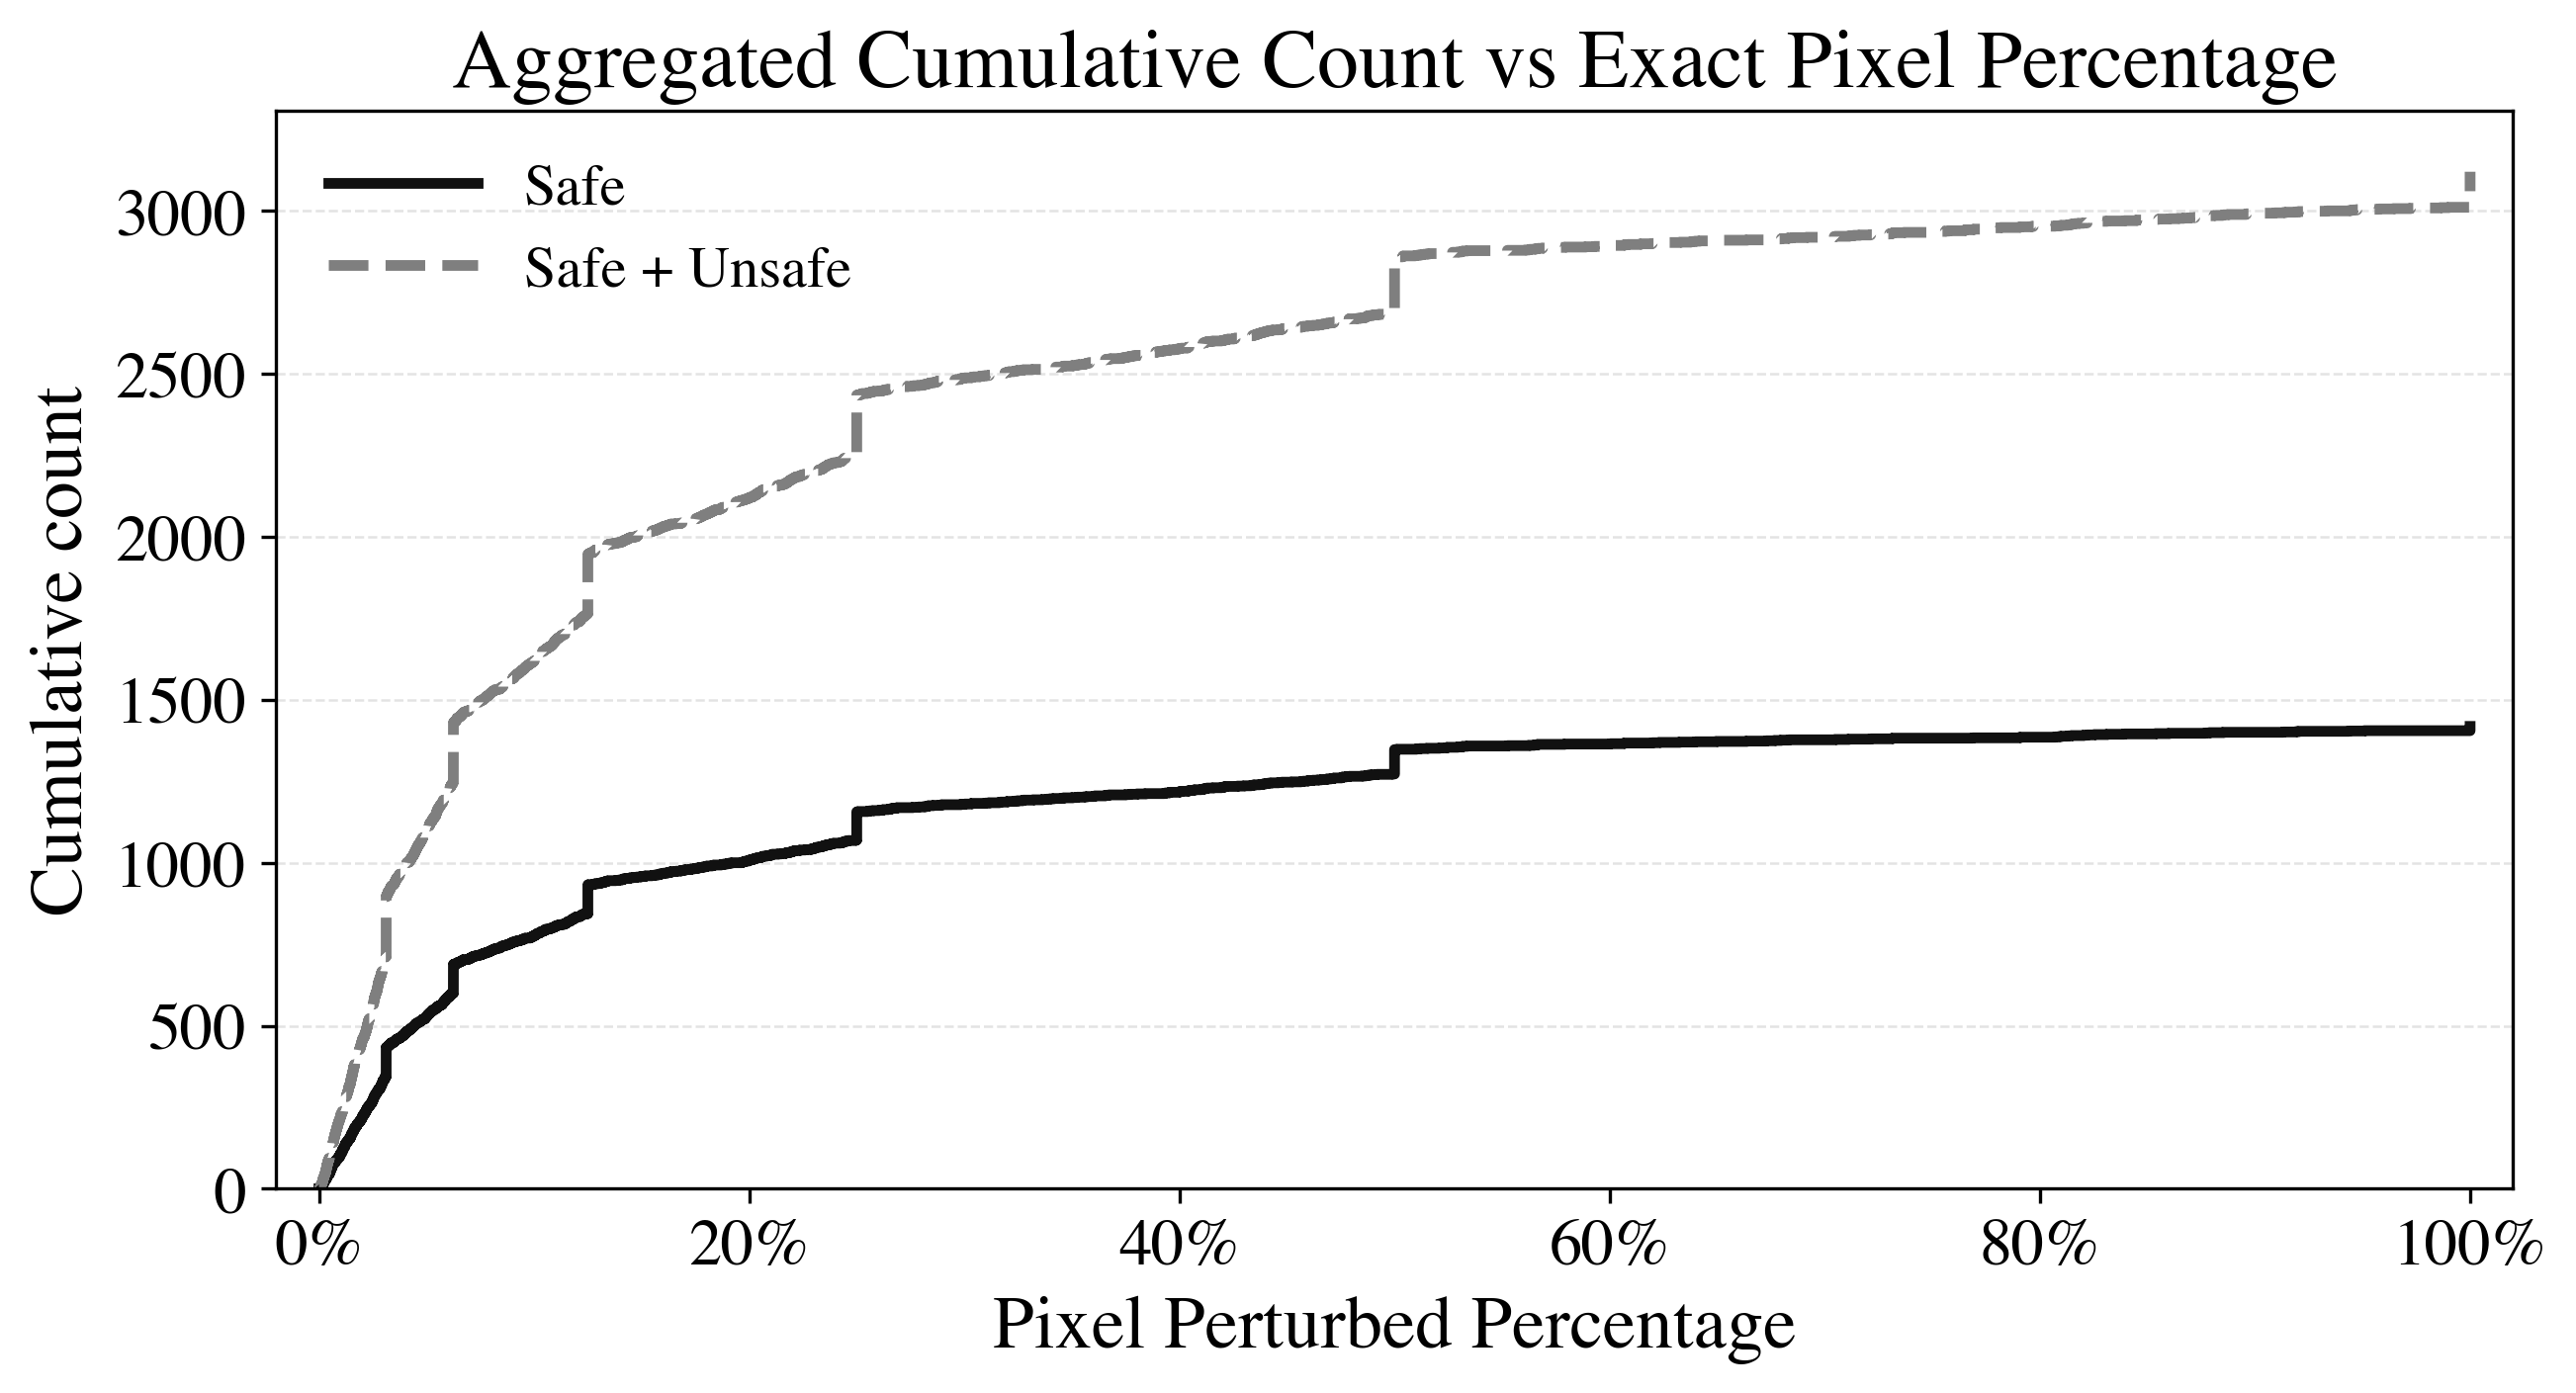

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

merged = pd.read_csv("imagenet_object_ratio_with_k_result_tag.csv")

step_all = (
    merged.assign(
        safe_count=(merged["result"] == "safe").astype(int),
        unsafe_count=(merged["result"] == "unsafe").astype(int),
        unknown_count=(merged["result"] == "unknown").astype(int),
    )
    .groupby("pixel_perturbed_percentage", as_index=False)
    .agg(
        safe_count=("safe_count", "sum"),
        unsafe_count=("unsafe_count", "sum"),
        unknown_count=("unknown_count", "sum"),
    )
    .sort_values("pixel_perturbed_percentage")
    .reset_index(drop=True)
)

step_all["safe_plus_unsafe_count"] = step_all["safe_count"] + step_all["unsafe_count"]
step_all["all_count"] = step_all["safe_plus_unsafe_count"] + step_all["unknown_count"]
step_all["safe_cumulative_count"] = step_all["safe_count"].cumsum()
step_all["unsafe_cumulative_count"] = step_all["unsafe_count"].cumsum()
step_all["unknown_cumulative_count"] = step_all["unknown_count"].cumsum()
step_all["safe_plus_unsafe_cumulative_count"] = step_all["safe_plus_unsafe_count"].cumsum()
step_all["all_cumulative_count"] = step_all["all_count"].cumsum()

step_safe_vs_all = step_all[
    [
        "pixel_perturbed_percentage",
        "safe_cumulative_count",
        "safe_plus_unsafe_cumulative_count",
    ]
].copy()

# step_all.to_csv(STEP_ALL_PATH, index=False)
# step_safe_vs_all.to_csv(STEP_SAFE_VS_ALL_PATH, index=False)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

plot_x = np.concatenate(([0.0], step_safe_vs_all["pixel_perturbed_percentage"].to_numpy()))
plot_safe = np.concatenate(([0], step_safe_vs_all["safe_cumulative_count"].to_numpy()))
plot_safe_plus_unsafe = np.concatenate(
    ([0], step_safe_vs_all["safe_plus_unsafe_cumulative_count"].to_numpy())
)

fig, ax = plt.subplots(figsize=(8.8, 4.8), dpi=300)
ax.step(plot_x, plot_safe, where="post", color="#111111", linewidth=2.6, label="Safe")
ax.step(
    plot_x,
    plot_safe_plus_unsafe,
    where="post",
    color="#7F7F7F",
    linewidth=2.6,
    linestyle="--",
    label="Safe + Unsafe",
)

ax.set_title("Aggregated Cumulative Count vs Exact Pixel Percentage")
ax.set_xlabel("Pixel Perturbed Percentage")
ax.set_ylabel("Cumulative count")
ax.set_xlim(-2, 102)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
ax.set_ylim(0, max(plot_safe_plus_unsafe) * 1.06)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.legend(loc="upper left", frameon=False, handlelength=2.6)
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
fig.tight_layout()


In [5]:
import pandas as pd

merged = pd.read_csv("imagenet_object_ratio_with_k_result_tag.csv")

df = merged.copy()

df["safe"] = (df["result"] == "safe").astype(int)
df["unsafe"] = (df["result"] == "unsafe").astype(int)
df["unknown"] = (df["result"] == "unknown").astype(int)
df["solved"] = df["result"].isin(["safe", "unsafe"]).astype(int)

label_map = {
    "whole-image": "Random whole-image",
    "object": "Object",
    "background": "Background",
}
df["plot_tag"] = df["tag"].map(label_map).fillna(df["tag"])

view = df[
    [
        "image",
        "tag",
        "plot_tag",
        "result",
        "k",
        "object_ratio",
        "background_ratio",
        "perturbed_pixel",
        "pixel_perturbed_percentage",
        "total_pixel",
        "safe",
        "unsafe",
        "unknown",
        "solved",
    ]
].copy()

print("Rows:", len(view))
print("Unique tags:", sorted(view["tag"].unique()))
print("Unique plot tags:", sorted(view["plot_tag"].unique()))
print("Unique k values:", sorted(view["k"].dropna().unique()))
print()
print(view.head(10))

Rows: 3258
Unique tags: ['background', 'object', 'whole-image']
Unique plot tags: ['Background', 'Object', 'Random whole-image']
Unique k values: [np.float64(1568.0), np.float64(3136.0), np.float64(6272.0), np.float64(12544.0), np.float64(25088.0), np.float64(50176.0)]

                         image          tag            plot_tag  result  \
0           n01443537_goldfish  whole-image  Random whole-image    safe   
1           n01443537_goldfish   background          Background    safe   
2           n01443537_goldfish       object              Object    safe   
3  n01484850_great_white_shark  whole-image  Random whole-image  unsafe   
4  n01484850_great_white_shark   background          Background  unsafe   
5  n01484850_great_white_shark       object              Object  unsafe   
6        n01491361_tiger_shark  whole-image  Random whole-image    safe   
7        n01491361_tiger_shark   background          Background    safe   
8        n01491361_tiger_shark       object           

In [6]:
summary = (
    view.groupby(["plot_tag", "result"], as_index=False)
        .size()
        .pivot(index="plot_tag", columns="result", values="size")
        .fillna(0)
        .astype(int)
)

print(summary)

result              safe  unknown  unsafe
plot_tag                                 
Background           497       23     566
Object               486       33     567
Random whole-image   435       83     568


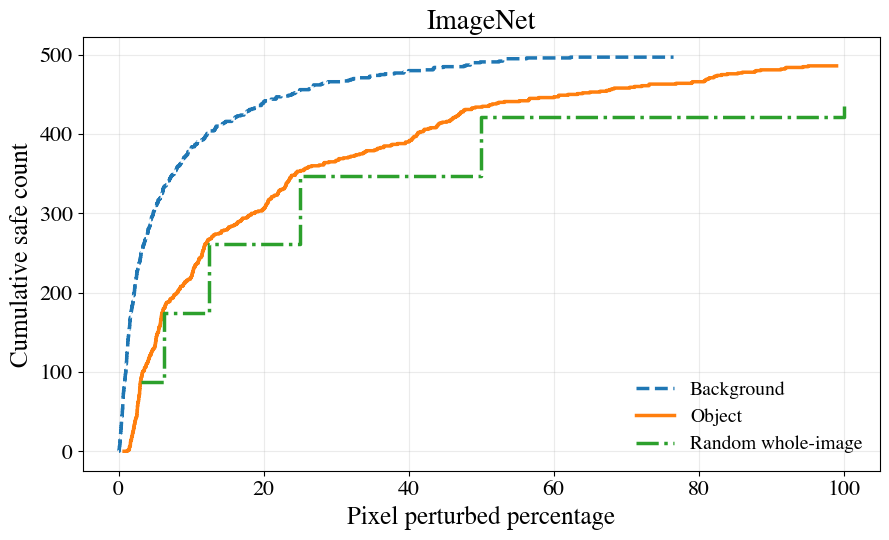

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Aggregate safe counts by support family and realized perturbed percentage
step_safe = (
    view.groupby(["plot_tag", "pixel_perturbed_percentage"], as_index=False)
        .agg(safe_count=("safe", "sum"))
        .sort_values(["plot_tag", "pixel_perturbed_percentage"])
)

# Cumulative safe count within each support family
step_safe["cum_safe"] = (
    step_safe.groupby("plot_tag")["safe_count"].cumsum()
)

# Plot
fig, ax = plt.subplots(figsize=(9, 5.5))

style_map = {
    "Background": "--",
    "Object": "-",
    "Random whole-image": "-.",
}

order = ["Background", "Object", "Random whole-image"]

for tag in order:
    g = step_safe[step_safe["plot_tag"] == tag]
    ax.step(
        g["pixel_perturbed_percentage"],
        g["cum_safe"],
        where="post",
        linestyle=style_map[tag],
        linewidth=2.5,
        label=tag,
    )

ax.set_xlabel("Pixel perturbed percentage")
ax.set_ylabel("Cumulative safe count")
ax.set_title("ImageNet")
ax.legend(frameon=False)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

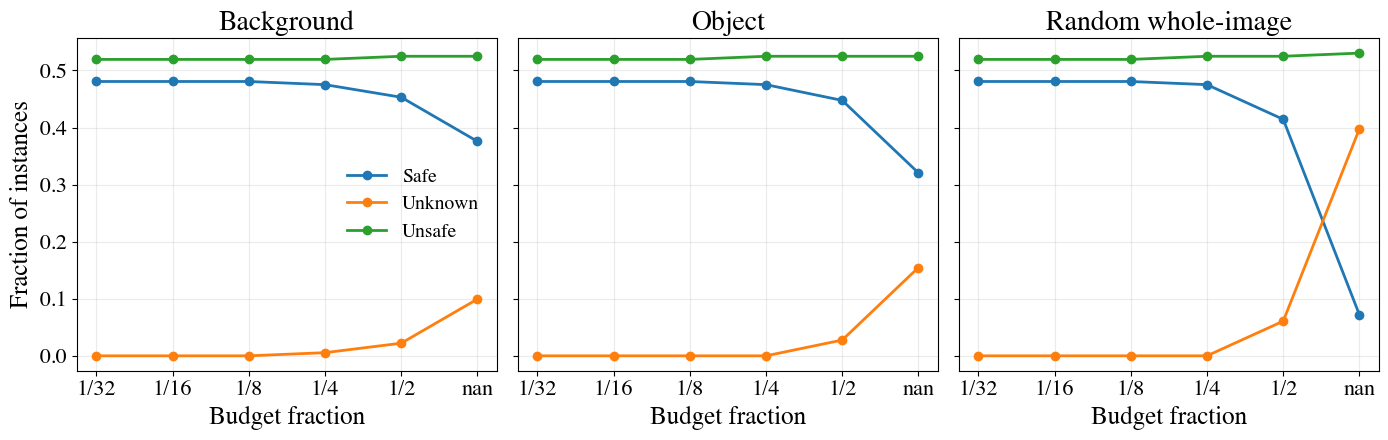

              plot_tag        k  budget_frac k_label  safe_rate  unknown_rate  \
0           Background   1568.0      0.03125    1/32   0.480663      0.000000   
1           Background   3136.0      0.06250    1/16   0.480663      0.000000   
2           Background   6272.0      0.12500     1/8   0.480663      0.000000   
3           Background  12544.0      0.25000     1/4   0.475138      0.005525   
4           Background  25088.0      0.50000     1/2   0.453039      0.022099   
5           Background  50176.0      1.00000  1.0000   0.375691      0.099448   
6               Object   1568.0      0.03125    1/32   0.480663      0.000000   
7               Object   3136.0      0.06250    1/16   0.480663      0.000000   
8               Object   6272.0      0.12500     1/8   0.480663      0.000000   
9               Object  12544.0      0.25000     1/4   0.475138      0.000000   
10              Object  25088.0      0.50000     1/2   0.447514      0.027624   
11              Object  5017

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

budget_summary = (
    view.groupby(["plot_tag", "k", "total_pixel"], as_index=False)
        .agg(
            n=("result", "size"),
            safe=("safe", "sum"),
            unsafe=("unsafe", "sum"),
            unknown=("unknown", "sum"),
        )
        .sort_values(["plot_tag", "k"])
)

budget_summary["safe_rate"] = budget_summary["safe"] / budget_summary["n"]
budget_summary["unsafe_rate"] = budget_summary["unsafe"] / budget_summary["n"]
budget_summary["unknown_rate"] = budget_summary["unknown"] / budget_summary["n"]

# Compute budget fraction robustly
budget_summary["budget_frac"] = budget_summary["k"] / budget_summary["total_pixel"]

def frac_label(x):
    if np.isclose(x, 1/32):
        return "1/32"
    elif np.isclose(x, 1/16):
        return "1/16"
    elif np.isclose(x, 1/8):
        return "1/8"
    elif np.isclose(x, 1/4):
        return "1/4"
    elif np.isclose(x, 1/2):
        return "1/2"
    else:
        return f"{x:.4f}"

budget_summary["k_label"] = budget_summary["budget_frac"].apply(frac_label)

order = ["1/32", "1/16", "1/8", "1/4", "1/2"]
tags = ["Background", "Object", "Random whole-image"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, tag in zip(axes, tags):
    g = budget_summary[budget_summary["plot_tag"] == tag].copy()
    g["k_label"] = pd.Categorical(g["k_label"], categories=order, ordered=True)
    g = g.sort_values("k_label")

    ax.plot(g["k_label"].astype(str), g["safe_rate"], marker="o", linewidth=2, label="Safe")
    ax.plot(g["k_label"].astype(str), g["unknown_rate"], marker="o", linewidth=2, label="Unknown")
    ax.plot(g["k_label"].astype(str), g["unsafe_rate"], marker="o", linewidth=2, label="Unsafe")

    ax.set_title(tag)
    ax.set_xlabel("Budget fraction")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Fraction of instances")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

print(budget_summary[["plot_tag", "k", "budget_frac", "k_label", "safe_rate", "unknown_rate", "unsafe_rate"]])

/var/folders/_n/3wz1tmjs1k75zkh7v9q7_1m40000gn/T/ipykernel_73305/2799032359.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["plot_tag", "frac_bin"], as_index=False)


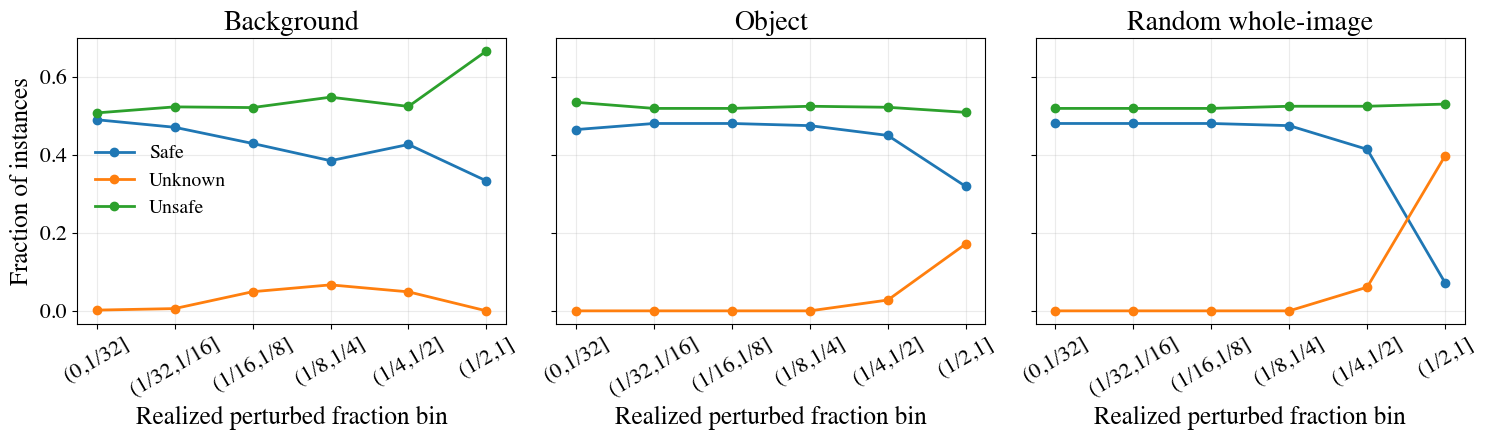

              plot_tag     frac_bin    n  safe  unsafe  unknown  safe_rate  \
0           Background     (0,1/32]  516   253     262        1   0.490310   
1           Background  (1/32,1/16]  172    81      90        1   0.470930   
2           Background   (1/16,1/8]  163    70      85        8   0.429448   
3           Background    (1/8,1/4]  135    52      74        9   0.385185   
4           Background    (1/4,1/2]   82    35      43        4   0.426829   
5           Background      (1/2,1]   18     6      12        0   0.333333   
6               Object     (0,1/32]  200    93     107        0   0.465000   
7               Object  (1/32,1/16]  181    87      94        0   0.480663   
8               Object   (1/16,1/8]  181    87      94        0   0.480663   
9               Object    (1/8,1/4]  181    86      95        0   0.475138   
10              Object    (1/4,1/2]  180    81      94        5   0.450000   
11              Object      (1/2,1]  163    52      83       28 

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df2 = view.copy()

# Use fraction rather than percent for binning convenience
df2["perturbed_frac"] = df2["pixel_perturbed_percentage"] / 100.0

# Bins chosen to align with your budget scales
bin_edges = [0, 1/32, 1/16, 1/8, 1/4, 1/2, 1.0 + 1e-9]
bin_labels = ["(0,1/32]", "(1/32,1/16]", "(1/16,1/8]", "(1/8,1/4]", "(1/4,1/2]", "(1/2,1]"]

df2["frac_bin"] = pd.cut(
    df2["perturbed_frac"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=False,
    right=True
)

binned = (
    df2.dropna(subset=["frac_bin"])
       .groupby(["plot_tag", "frac_bin"], as_index=False)
       .agg(
           n=("result", "size"),
           safe=("safe", "sum"),
           unsafe=("unsafe", "sum"),
           unknown=("unknown", "sum"),
       )
)

binned["safe_rate"] = binned["safe"] / binned["n"]
binned["unsafe_rate"] = binned["unsafe"] / binned["n"]
binned["unknown_rate"] = binned["unknown"] / binned["n"]

tags = ["Background", "Object", "Random whole-image"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, tag in zip(axes, tags):
    g = binned[binned["plot_tag"] == tag].copy()
    g["frac_bin"] = pd.Categorical(g["frac_bin"], categories=bin_labels, ordered=True)
    g = g.sort_values("frac_bin")

    ax.plot(g["frac_bin"].astype(str), g["safe_rate"], marker="o", linewidth=2, label="Safe")
    ax.plot(g["frac_bin"].astype(str), g["unknown_rate"], marker="o", linewidth=2, label="Unknown")
    ax.plot(g["frac_bin"].astype(str), g["unsafe_rate"], marker="o", linewidth=2, label="Unsafe")

    ax.set_title(tag)
    ax.set_xlabel("Realized perturbed fraction bin")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Fraction of instances")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

print(binned.sort_values(["plot_tag", "frac_bin"]))

In [11]:
count_table = (
    binned.pivot(index="frac_bin", columns="plot_tag", values="n")
    .fillna(0)
    .astype(int)
)

print(count_table)

plot_tag     Background  Object  Random whole-image
frac_bin                                           
(0,1/32]            516     200                 181
(1/32,1/16]         172     181                 181
(1/16,1/8]          163     181                 181
(1/8,1/4]           135     181                 181
(1/4,1/2]            82     180                 181
(1/2,1]              18     163                 181


In [12]:
import pandas as pd
import numpy as np

merged = pd.read_csv("imagenet_object_ratio_with_k_result_tag.csv")

df = merged.copy()

# Keep only the columns we need
df = df[
    [
        "image",
        "tag",
        "result",
        "k",
        "pixel_perturbed_percentage",
        "perturbed_pixel",
        "total_pixel",
    ]
].copy()

# Realized perturbed fraction in [0,1]
df["perturbed_frac"] = df["pixel_perturbed_percentage"] / 100.0

# Dense object-mask rows: k == total_pixel within numerical tolerance
object_dense = df[
    (df["tag"] == "object") &
    np.isclose(df["k"], df["total_pixel"])
].copy()

# Random whole-image rows: the sampled whole-image supports
whole_random = df[df["tag"] == "whole-image"].copy()

print("Dense object rows:", len(object_dense))
print("Random whole-image rows:", len(whole_random))
print("Unique dense-object images:", object_dense["image"].nunique())
print("Unique whole-image images:", whole_random["image"].nunique())

Dense object rows: 181
Random whole-image rows: 1086
Unique dense-object images: 181
Unique whole-image images: 181


In [13]:
matched_rows = []

for _, obj_row in object_dense.iterrows():
    image_id = obj_row["image"]
    candidates = whole_random[whole_random["image"] == image_id].copy()
    
    if len(candidates) == 0:
        continue
    
    candidates["abs_diff"] = np.abs(
        candidates["perturbed_frac"] - obj_row["perturbed_frac"]
    )
    
    best = candidates.sort_values(
        ["abs_diff", "perturbed_frac"]
    ).iloc[0]
    
    matched_rows.append(
        {
            "image": image_id,
            "object_result": obj_row["result"],
            "object_frac": obj_row["perturbed_frac"],
            "object_pct": obj_row["pixel_perturbed_percentage"],
            "random_result": best["result"],
            "random_frac": best["perturbed_frac"],
            "random_pct": best["pixel_perturbed_percentage"],
            "random_k": best["k"],
            "abs_diff": best["abs_diff"],
        }
    )

matched = pd.DataFrame(matched_rows)

print("Matched pairs:", len(matched))
matched.head(10)

Matched pairs: 181


,image,object_result,object_frac,object_pct,random_result,random_frac,random_pct,random_k,abs_diff
0,n01443537_goldfish,safe,0.812998,81.299825,unknown,1.0,100.0,50176.0,0.187002
1,n01484850_great_white_shark,unsafe,0.902264,90.226403,unsafe,1.0,100.0,50176.0,0.097736
2,n01491361_tiger_shark,unknown,0.975466,97.546636,unknown,1.0,100.0,50176.0,0.024534
3,n01496331_electric_ray,unknown,0.936145,93.614477,unknown,1.0,100.0,50176.0,0.063855
4,n01514668_cock,unsafe,0.944794,94.479432,unsafe,1.0,100.0,50176.0,0.055206
5,n01514859_hen,unsafe,0.638253,63.825335,unsafe,0.5,50.0,25088.0,0.138253
6,n01518878_ostrich,unsafe,0.828862,82.886240,unsafe,1.0,100.0,50176.0,0.171138
7,n01530575_brambling,unsafe,0.887416,88.741629,unsafe,1.0,100.0,50176.0,0.112584
8,n02033041_dowitcher,safe,0.877073,87.707270,unknown,1.0,100.0,50176.0,0.122927
9,n01742172_boa_constrictor,unknown,0.801678,80.167809,unknown,1.0,100.0,50176.0,0.198322


In [14]:
quality_summary = pd.DataFrame(
    {
        "metric": [
            "matched pairs",
            "mean abs diff",
            "median abs diff",
            "max abs diff",
        ],
        "value": [
            len(matched),
            matched["abs_diff"].mean(),
            matched["abs_diff"].median(),
            matched["abs_diff"].max(),
        ],
    }
)

print(quality_summary)

            metric       value
0    matched pairs  181.000000
1    mean abs diff    0.124953
2  median abs diff    0.124601
3     max abs diff    0.249880


In [15]:
quality_summary_pct = pd.DataFrame(
    {
        "metric": [
            "matched pairs",
            "mean abs diff (%)",
            "median abs diff (%)",
            "max abs diff (%)",
        ],
        "value": [
            len(matched),
            100 * matched["abs_diff"].mean(),
            100 * matched["abs_diff"].median(),
            100 * matched["abs_diff"].max(),
        ],
    }
)

print(quality_summary_pct)

                metric       value
0        matched pairs  181.000000
1    mean abs diff (%)   12.495276
2  median abs diff (%)   12.460140
3     max abs diff (%)   24.988042


In [16]:
outcome_table = pd.crosstab(
    matched["object_result"],
    matched["random_result"],
    rownames=["Object"],
    colnames=["Matched random whole-image"],
    dropna=False,
)

print(outcome_table)

Matched random whole-image  safe  unknown  unsafe
Object                                           
safe                          38       20       0
unknown                        2       26       0
unsafe                         0        0      95


In [17]:
score_map = {"unsafe": 0, "unknown": 1, "safe": 2}

matched["object_score"] = matched["object_result"].map(score_map)
matched["random_score"] = matched["random_result"].map(score_map)

matched["comparison"] = np.where(
    matched["object_score"] > matched["random_score"],
    "Object better",
    np.where(
        matched["object_score"] < matched["random_score"],
        "Random better",
        "Equal",
    ),
)

comparison_summary = (
    matched["comparison"]
    .value_counts()
    .rename_axis("comparison")
    .reset_index(name="count")
)

print(comparison_summary)

      comparison  count
0          Equal    159
1  Object better     20
2  Random better      2


In [18]:
safe_summary = pd.DataFrame(
    {
        "setting": ["Dense object", "Matched random whole-image"],
        "safe_count": [
            (matched["object_result"] == "safe").sum(),
            (matched["random_result"] == "safe").sum(),
        ],
        "unknown_count": [
            (matched["object_result"] == "unknown").sum(),
            (matched["random_result"] == "unknown").sum(),
        ],
        "unsafe_count": [
            (matched["object_result"] == "unsafe").sum(),
            (matched["random_result"] == "unsafe").sum(),
        ],
    }
)

print(safe_summary)

                      setting  safe_count  unknown_count  unsafe_count
0                Dense object          58             28            95
1  Matched random whole-image          40             46            95


In [19]:
paper_table = pd.DataFrame(
    {
        "Metric": [
            "Matched pairs",
            "Mean abs. matching error (%)",
            "Median abs. matching error (%)",
            "Max abs. matching error (%)",
            "Object better",
            "Equal",
            "Random better",
            "Object safe",
            "Matched random safe",
        ],
        "Value": [
            len(matched),
            round(100 * matched["abs_diff"].mean(), 3),
            round(100 * matched["abs_diff"].median(), 3),
            round(100 * matched["abs_diff"].max(), 3),
            int((matched["comparison"] == "Object better").sum()),
            int((matched["comparison"] == "Equal").sum()),
            int((matched["comparison"] == "Random better").sum()),
            int((matched["object_result"] == "safe").sum()),
            int((matched["random_result"] == "safe").sum()),
        ],
    }
)

print(paper_table.to_string(index=False))

                        Metric   Value
                 Matched pairs 181.000
  Mean abs. matching error (%)  12.495
Median abs. matching error (%)  12.460
   Max abs. matching error (%)  24.988
                 Object better  20.000
                         Equal 159.000
                 Random better   2.000
                   Object safe  58.000
           Matched random safe  40.000


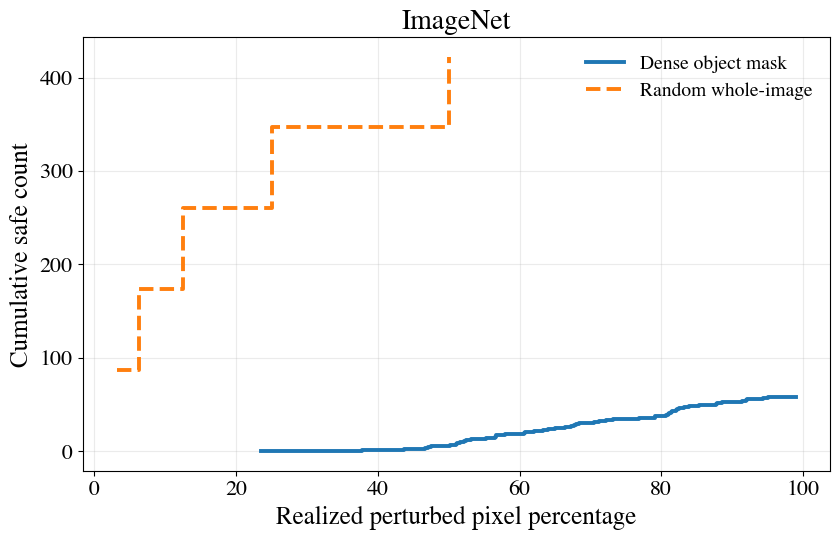

Dense object safe total: 58
Random whole-image safe total: 422


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_csv("imagenet_object_ratio_with_k_result_tag.csv")

df = merged.copy()
df["safe"] = (df["result"] == "safe").astype(int)

# Realized perturbed fraction in [0,1]
df["perturbed_frac"] = df["pixel_perturbed_percentage"] / 100.0

# Dense object-mask results: k == total_pixel
object_dense = df[
    (df["tag"] == "object") &
    np.isclose(df["k"], df["total_pixel"])
].copy()

# Random whole-image results: keep all sampled whole-image supports except dense whole image
whole_random = df[
    (df["tag"] == "whole-image") &
    (~np.isclose(df["k"], df["total_pixel"]))
].copy()

# Aggregate safe counts by realized perturbed fraction
obj_step = (
    object_dense.groupby("perturbed_frac", as_index=False)
    .agg(safe_count=("safe", "sum"))
    .sort_values("perturbed_frac")
)
obj_step["cum_safe"] = obj_step["safe_count"].cumsum()

rand_step = (
    whole_random.groupby("perturbed_frac", as_index=False)
    .agg(safe_count=("safe", "sum"))
    .sort_values("perturbed_frac")
)
rand_step["cum_safe"] = rand_step["safe_count"].cumsum()

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.step(
    obj_step["perturbed_frac"] * 100,
    obj_step["cum_safe"],
    where="post",
    linewidth=2.8,
    label="Dense object mask",
)

ax.step(
    rand_step["perturbed_frac"] * 100,
    rand_step["cum_safe"],
    where="post",
    linewidth=2.8,
    linestyle="--",
    label="Random whole-image",
)

ax.set_xlabel("Realized perturbed pixel percentage")
ax.set_ylabel("Cumulative safe count")
ax.set_title("ImageNet")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print("Dense object safe total:", object_dense["safe"].sum())
print("Random whole-image safe total:", whole_random["safe"].sum())


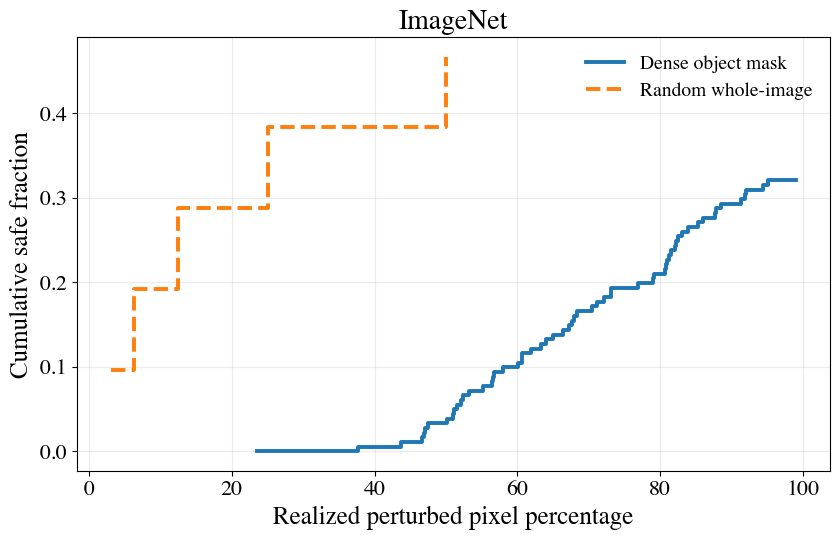

Dense object rows: 181 safe: 58
Random whole-image rows: 905 safe: 422


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_csv("imagenet_object_ratio_with_k_result_tag.csv")

df = merged.copy()
df["safe"] = (df["result"] == "safe").astype(int)
df["perturbed_frac"] = df["pixel_perturbed_percentage"] / 100.0

# Dense object-mask results: one per image
object_dense = df[
    (df["tag"] == "object") &
    np.isclose(df["k"], df["total_pixel"])
].copy()

# Random whole-image sparse supports only
whole_random = df[
    (df["tag"] == "whole-image") &
    (~np.isclose(df["k"], df["total_pixel"]))
].copy()

def cumulative_safe_fraction(data):
    g = (
        data.groupby("perturbed_frac", as_index=False)
            .agg(safe_count=("safe", "sum"),
                 total_count=("safe", "size"))
            .sort_values("perturbed_frac")
    )
    g["cum_safe"] = g["safe_count"].cumsum()
    g["cum_total"] = g["total_count"].cumsum()
    g["cum_safe_frac_all"] = g["cum_safe"] / len(data)
    return g

obj_curve = cumulative_safe_fraction(object_dense)
rand_curve = cumulative_safe_fraction(whole_random)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.step(
    obj_curve["perturbed_frac"] * 100,
    obj_curve["cum_safe_frac_all"],
    where="post",
    linewidth=2.8,
    label="Dense object mask",
)

ax.step(
    rand_curve["perturbed_frac"] * 100,
    rand_curve["cum_safe_frac_all"],
    where="post",
    linewidth=2.8,
    linestyle="--",
    label="Random whole-image",
)

ax.set_xlabel("Realized perturbed pixel percentage")
ax.set_ylabel("Cumulative safe fraction")
ax.set_title("ImageNet")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print("Dense object rows:", len(object_dense), "safe:", object_dense["safe"].sum())
print("Random whole-image rows:", len(whole_random), "safe:", whole_random["safe"].sum())


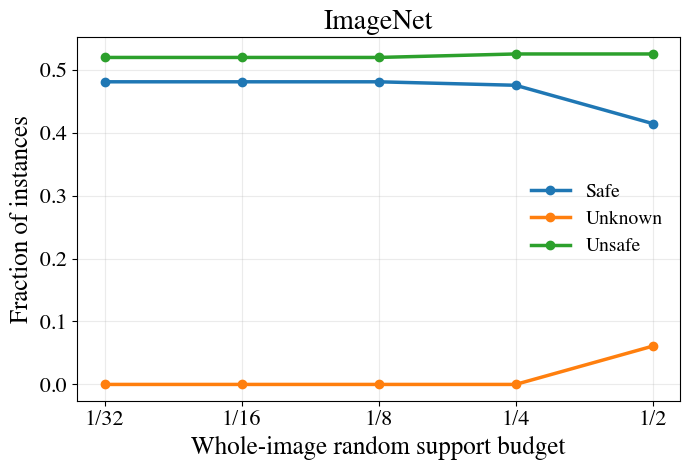

  label  safe  unknown  unsafe  safe_rate  unknown_rate  unsafe_rate
0  1/32    87        0      94   0.480663      0.000000     0.519337
1  1/16    87        0      94   0.480663      0.000000     0.519337
2   1/8    87        0      94   0.480663      0.000000     0.519337
3   1/4    86        0      95   0.475138      0.000000     0.524862
4   1/2    75       11      95   0.414365      0.060773     0.524862


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_csv("imagenet_object_ratio_with_k_result_tag.csv")

df = merged.copy()
df["safe"] = (df["result"] == "safe").astype(int)
df["unsafe"] = (df["result"] == "unsafe").astype(int)
df["unknown"] = (df["result"] == "unknown").astype(int)

rand = df[
    (df["tag"] == "whole-image") &
    (~np.isclose(df["k"], df["total_pixel"]))
].copy()

rand["budget_frac"] = rand["k"] / rand["total_pixel"]

summary = (
    rand.groupby("budget_frac", as_index=False)
        .agg(
            n=("result", "size"),
            safe=("safe", "sum"),
            unsafe=("unsafe", "sum"),
            unknown=("unknown", "sum"),
        )
        .sort_values("budget_frac")
)

summary["safe_rate"] = summary["safe"] / summary["n"]
summary["unsafe_rate"] = summary["unsafe"] / summary["n"]
summary["unknown_rate"] = summary["unknown"] / summary["n"]

def frac_label(x):
    if np.isclose(x, 1/32):
        return "1/32"
    if np.isclose(x, 1/16):
        return "1/16"
    if np.isclose(x, 1/8):
        return "1/8"
    if np.isclose(x, 1/4):
        return "1/4"
    if np.isclose(x, 1/2):
        return "1/2"
    return f"{x:.4f}"

summary["label"] = summary["budget_frac"].apply(frac_label)

fig, ax = plt.subplots(figsize=(7, 4.8))

ax.plot(summary["label"], summary["safe_rate"], marker="o", linewidth=2.5, label="Safe")
ax.plot(summary["label"], summary["unknown_rate"], marker="o", linewidth=2.5, label="Unknown")
ax.plot(summary["label"], summary["unsafe_rate"], marker="o", linewidth=2.5, label="Unsafe")

ax.set_xlabel("Whole-image random support budget")
ax.set_ylabel("Fraction of instances")
ax.set_title("ImageNet")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(summary[["label", "safe", "unknown", "unsafe", "safe_rate", "unknown_rate", "unsafe_rate"]])

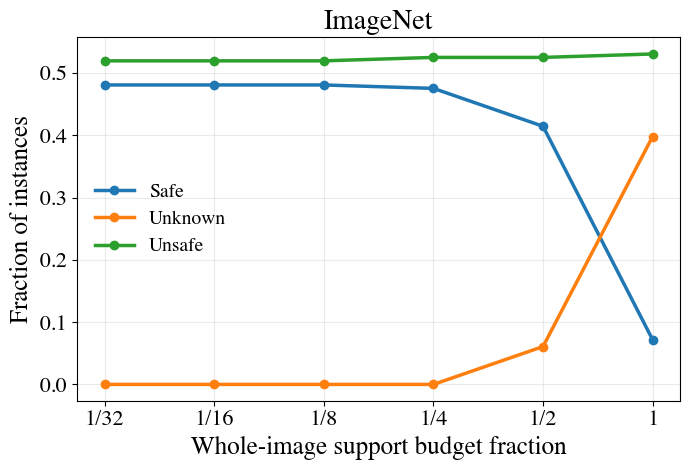

  label  safe  unknown  unsafe  safe_rate  unknown_rate  unsafe_rate
0  1/32    87        0      94   0.480663      0.000000     0.519337
1  1/16    87        0      94   0.480663      0.000000     0.519337
2   1/8    87        0      94   0.480663      0.000000     0.519337
3   1/4    86        0      95   0.475138      0.000000     0.524862
4   1/2    75       11      95   0.414365      0.060773     0.524862
5     1    13       72      96   0.071823      0.397790     0.530387


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_csv("imagenet_object_ratio_with_k_result_tag.csv")

df = merged.copy()
df["safe"] = (df["result"] == "safe").astype(int)
df["unsafe"] = (df["result"] == "unsafe").astype(int)
df["unknown"] = (df["result"] == "unknown").astype(int)

rand = df[df["tag"] == "whole-image"].copy()
rand["budget_frac"] = rand["k"] / rand["total_pixel"]

summary = (
    rand.groupby("budget_frac", as_index=False)
        .agg(
            n=("result", "size"),
            safe=("safe", "sum"),
            unsafe=("unsafe", "sum"),
            unknown=("unknown", "sum"),
        )
        .sort_values("budget_frac")
)

summary["safe_rate"] = summary["safe"] / summary["n"]
summary["unsafe_rate"] = summary["unsafe"] / summary["n"]
summary["unknown_rate"] = summary["unknown"] / summary["n"]

def frac_label(x):
    if np.isclose(x, 1/32):
        return "1/32"
    if np.isclose(x, 1/16):
        return "1/16"
    if np.isclose(x, 1/8):
        return "1/8"
    if np.isclose(x, 1/4):
        return "1/4"
    if np.isclose(x, 1/2):
        return "1/2"
    if np.isclose(x, 1):
        return "1"
    return f"{x:.4f}"

summary["label"] = summary["budget_frac"].apply(frac_label)

order = ["1/32", "1/16", "1/8", "1/4", "1/2", "1"]
summary["label"] = pd.Categorical(summary["label"], categories=order, ordered=True)
summary = summary.sort_values("label")

fig, ax = plt.subplots(figsize=(7, 4.8))

ax.plot(summary["label"], summary["safe_rate"], marker="o", linewidth=2.5, label="Safe")
ax.plot(summary["label"], summary["unknown_rate"], marker="o", linewidth=2.5, label="Unknown")
ax.plot(summary["label"], summary["unsafe_rate"], marker="o", linewidth=2.5, label="Unsafe")

ax.set_xlabel("Whole-image support budget fraction")
ax.set_ylabel("Fraction of instances")
ax.set_title("ImageNet")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(summary[["label", "safe", "unknown", "unsafe", "safe_rate", "unknown_rate", "unsafe_rate"]])